### Importing necessary modules

In [19]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
import tensorflow as tf                                                                 # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
import random                                                                           # type: ignore
import cartopy.crs as ccrs                                                              # type: ignore
import cartopy.feature as cfeature                                                      # type: ignore
np.random.seed(42)

In [20]:
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [21]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

### Importing dataset

### Exploratory data analysis

In [22]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [23]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [24]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t0
t0 = "year,month,day,hour,minute,"

# latitude and longitude, wavelet power, storm size and distance to Dakar
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

# combining all fields to form the feature input
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')

In [25]:
to_scale = wavelet_power + storm_size + distance

In [26]:
model = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t3.keras")

In [27]:
scaler = load('/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Dakar-t3.bin')

Computing the average wavelet power

In [28]:
mean_wp = 3430.40
median_wp = 2266.0

mean_size = 7460.30
median_size = 5000.0

In [29]:
def create_storm():
    return {
        'year': [], 
        'month': [], 
        'day': [], 
        'hour': [], 
        'minute': [], 
        'lat1': [], 
        'lon1': [], 
        'lat2': [], 
        'lon2': [], 
        'lat3': [], 
        'lon3': [], 
        'lat4': [], 
        'lon4': [], 
        'lat5': [], 
        'lon5': [], 
        'wp1': [], 
        'wp2': [], 
        'wp3': [], 
        'wp4': [], 
        'wp5': [], 
        'size1': [], 
        'size2': [], 
        'size3': [], 
        'size4': [], 
        'size5': [], 
        'ds1': [], 
        'ds2': [], 
        'ds3': [], 
        'ds4': [], 
        'ds5': [], 
    }

For reproducibility

In [30]:
rng1 = np.random.RandomState(26)
rng2 = np.random.RandomState(21)
def generate_geo_coords(lat_min, lat_max, lon_min, lon_max):
    artificial_storm_lat = round(rng1.uniform(lat_min, lat_max), 6)
    artificial_storm_lon = round(rng1.uniform(lon_min, lon_max), 6)
    return artificial_storm_lat, artificial_storm_lon

In [31]:
def distance_to_Dakar(lat, lon):
    Dakar_lon = -17.467686
    Dakar_lat = 14.716677
    Dakar_y, Dakar_x = nflics.X0(Dakar_lat, Dakar_lon)
    y, x = nflics.X0(lat, lon)
    return round(np.sqrt((y - Dakar_y)**2 + (x - Dakar_x)**2), 4)

In [32]:
number_of_data_points = 1
number_of_storms_to_generate = 1
number_of_storms_in_model = 5

In [33]:
def generate_a_storm_cluster():
    lat_center, lon_center = generate_geo_coords(10, 19, -18.2, -10)
    lat_clusters = []
    lon_clusters = []    
    for _ in range(5):
        lat_candidate = lat_center + random.normalvariate(0,0.2)    
        lat_clusters.append(lat_candidate)    
        lon_candidate = lon_center + random.normalvariate(0,0.2)
        lon_clusters.append(lon_candidate)
    return lat_center, lon_center, lat_clusters, lon_clusters

In [34]:
number_of_simulations = 500

In [35]:
lons = []
lats = []
prob = []

for n in range(number_of_simulations):
    artificial_storms = create_storm()
    for _ in range(number_of_data_points):
        year, month, day, hour, minute = 2020, 7, 15, 18, 0
        artificial_storms["year"].append(year)
        artificial_storms["month"].append(month)
        artificial_storms["day"].append(day)
        artificial_storms["hour"].append(hour)
        artificial_storms["minute"].append(minute)
        lat_center, lon_center, lat_candidates, lon_candidates = generate_a_storm_cluster()
        for j in range(1, number_of_storms_in_model + 1):                        
            artificial_storm_lat, artificial_storm_lon = lat_candidates[j-1], lon_candidates[j-1]  #field name indices start from 1
            artificial_storms[f"lat{j}"].append(artificial_storm_lat)
            artificial_storms[f"lon{j}"].append(artificial_storm_lon)
            d_to_Dakar = distance_to_Dakar(artificial_storm_lat, artificial_storm_lon)
            artificial_storms[f"ds{j}"].append(d_to_Dakar)
            artificial_storms[f"wp{j}"].append(median_wp)
            artificial_storms[f"size{j}"].append(median_size)        

        raw_artificial_storm_data = pd.DataFrame.from_dict(artificial_storms, orient='columns')
        artificial_storm_data = log_transform(raw_artificial_storm_data, to_scale.split(',')[:-1])
        artificial_storm_data = sqrt_transform(artificial_storm_data, t0.split(',')[:-1])
        x_new = artificial_storm_data[artificial_storms.keys()]
        x_new_std = scaler.transform(x_new)
        y_new_pred = model.predict(x_new_std)
        y_artificial_pred = y_new_pred.flatten()

        lons.append(lon_center)
        lats.append(lat_center)
        prob.append(y_artificial_pred[0])
        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━

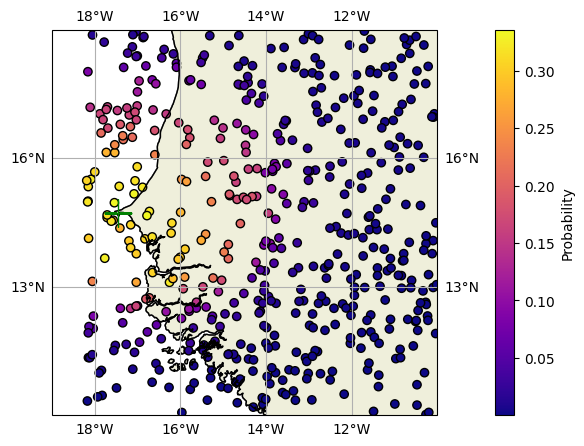

In [36]:
fig = plt.figure(figsize=(15, 5))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-19, -10, 10, 19], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.gridlines(xlocs=np.arange(-18,- 10, 2), ylocs=np.array([10, 13, 16]), draw_labels=True, crs=ccrs.PlateCarree())    



plt.plot(-17.4677, 14.7167, marker="+", color="green", markersize=20)
plt.scatter(lons, lats, c=prob, cmap='plasma', edgecolors='k')
plt.colorbar(label='Probability')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.title('Probability of storm in Dakar at t0+1h given a storms location at t0')
plt.show()
plt.show()